# Translation every thing in english vs MultiLingual Embedings
1. Machine Translation can change meaning(the hook words would be different in differnt languages)
[Original Hindi:
फ्री रिचार्ज ऑफर

Correct meaning:
Free recharge offer

Possible translation error:
Recharge without cost promotion]
2. Translation cost very expensive

# Install Dependencies

In [1]:
!pip install sentence-transformers

# Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# METHOD 1: TF-IDF + Logistic Regression

In [3]:
def tfidf_lr(newtexts,newlabels):
    tfidf = TfidfVectorizer(max_df=0.95, min_df=0.001)

    X_tfidf = tfidf.fit_transform(newtexts)

    X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
        X_tfidf,
        newlabels,
        test_size=0.2,
        stratify=newlabels,
        random_state=42
    )

    lr_tfidf = LogisticRegression(max_iter=2000,class_weight="balanced")
    lr_tfidf.fit(X_train_tfidf, y_train)

    y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

    tfidf_results = {
        "accuracy": accuracy_score(y_test, y_pred_tfidf),
        "precision": precision_score(y_test, y_pred_tfidf),
        "recall": recall_score(y_test, y_pred_tfidf),
        "f1": f1_score(y_test, y_pred_tfidf)
        }

    return tfidf_results

# METHOD 2: Multilingual Embeddings + Logistic Regression

In [4]:
def multi_embed(newtexts,newlabels):
    model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    if type(newtexts)!=list:
        newtexts = newtexts.tolist()

    X_embed = model.encode(
    newtexts,
    batch_size=32,
    show_progress_bar=True
    )

    print("Embedding shape:", X_embed.shape)
    X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_embed,
    newlabels,
    test_size=0.2,
    stratify=newlabels,
    random_state=42
    )

    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(X_train_emb, y_train)

    y_pred_embed = clf.predict(X_test_emb)

    embed_results = {
    "accuracy": accuracy_score(y_test, y_pred_embed),
    "precision": precision_score(y_test, y_pred_embed),
    "recall": recall_score(y_test, y_pred_embed),
    "f1": f1_score(y_test, y_pred_embed)
    }

    return embed_results

# loading rajnathpatel datasets(machine translated)

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/rajnathpatel/multilingual-spam-data/data-en-hi-de-fr.csv")

texts = []
labels = []

for _, row in df.iterrows():

    for col in ["text", "text_hi", "text_de", "text_fr"]:
        if pd.notna(row[col]):
            texts.append(str(row[col]))
            labels.append(row["labels"])

# Convert
texts = np.array(texts)
labels = np.array([1 if l == "spam" else 0 for l in labels])

print("Dataset size:", len(texts))
print("Label distribution:", np.unique(labels, return_counts=True))

Dataset size: 22288
Label distribution: (array([0, 1]), array([19300,  2988]))


# comparison on machine translates data set

In [6]:
import pandas as pd

tfidf_results=tfidf_lr(texts,labels)
embed_results=multi_embed(texts,labels)
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + LR", "Multilingual Embedding + LR"],
    "Accuracy": [tfidf_results["accuracy"], embed_results["accuracy"]],
    "Precision": [tfidf_results["precision"], embed_results["precision"]],
    "Recall": [tfidf_results["recall"], embed_results["recall"]],
    "F1 Score": [tfidf_results["f1"], embed_results["f1"]],
})

print("\n===== FINAL COMPARISON =====")
print(comparison_df)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/697 [00:00<?, ?it/s]

Embedding shape: (22288, 384)

===== FINAL COMPARISON =====
                         Model  Accuracy  Precision    Recall  F1 Score
0                  TF-IDF + LR  0.958950   0.803807  0.918060  0.857143
1  Multilingual Embedding + LR  0.975101   0.868381  0.959866  0.911835


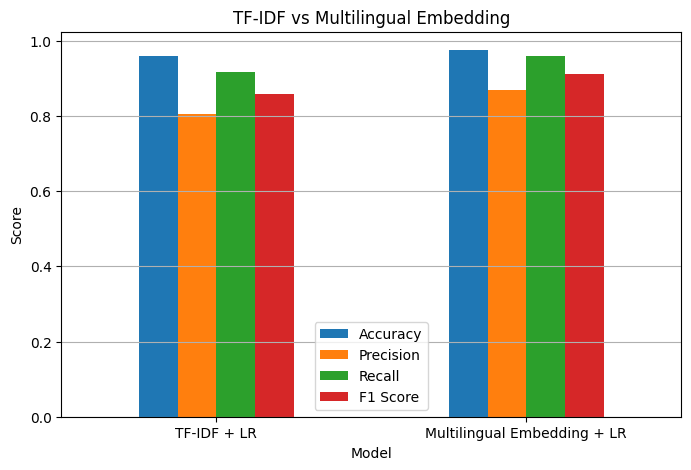

In [7]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("TF-IDF vs Multilingual Embedding")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

# IIIT-D Hindi SMS Dataset

# About_Data_Set

1. We avoid machine-translated datasets and use only native Hindi and Indian SMS corpora to ensure linguistic authenticity
2. Data is taken from https://india-data.org/
3. contains 2000+ messages
5. These are origianl messages not machine translated

In [8]:
import os
import pandas as pd

# Paths (update if needed)
ham_path = "/kaggle/input/datasets/charanpinniboyina/original-sms-data-from-iiitd/IIIT-D_SMS_Dataset/Ham SMSes"
spam_path = "/kaggle/input/datasets/charanpinniboyina/original-sms-data-from-iiitd/IIIT-D_SMS_Dataset/Spam SMSes"

data = []

# 🔹 Load HAM (label = 0)
for file in os.listdir(ham_path):
    file_path = os.path.join(ham_path, file)
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
        data.append([text, 0])   # 0 = ham

# 🔹 Load SPAM (label = 1)
for file in os.listdir(spam_path):
    file_path = os.path.join(spam_path, file)
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
        data.append([text, 1])   # 1 = spam

# 🔹 Create DataFrame
df = pd.DataFrame(data, columns=["text", "label"])

# 🔹 Shuffle (important)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 🔹 Preview
df.head()
    

,text,label
0,MJoy - a one stop shop for all the services th...,1
1,i am... that's why i asked you... now just study.,0
2,"Dirty Picture,Blyk on Aircel thanks you for be...",1
3,I didn't send u anythin now.,0
4,Payein har din 1 LOVE TIP aur 1 PYAAR bhari SH...,1


In [9]:
texts = []
labels = []

for row, label in zip(df["text"], df["label"]):
    texts.append(str(row))
    labels.append(label)

# comparison on iitd-sms data

In [10]:
import pandas as pd

tfidf_results=tfidf_lr(texts,labels)
embed_results=multi_embed(texts,labels)
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + LR", "Multilingual Embedding + LR"],
    "Accuracy": [tfidf_results["accuracy"], embed_results["accuracy"]],
    "Precision": [tfidf_results["precision"], embed_results["precision"]],
    "Recall": [tfidf_results["recall"], embed_results["recall"]],
    "F1 Score": [tfidf_results["f1"], embed_results["f1"]],
})

print("\n===== FINAL COMPARISON =====")
print(comparison_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (2000, 384)

===== FINAL COMPARISON =====
                         Model  Accuracy  Precision  Recall  F1 Score
0                  TF-IDF + LR     0.960   0.938095   0.985  0.960976
1  Multilingual Embedding + LR     0.965   0.960396   0.970  0.965174


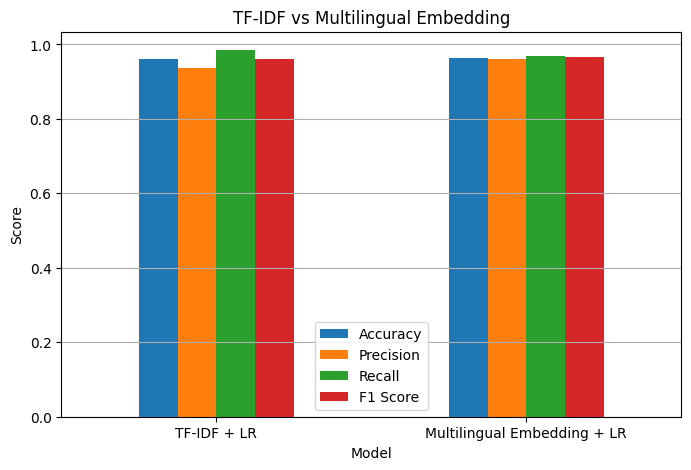

In [11]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("TF-IDF vs Multilingual Embedding")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()